# How to use surrogate gradients

**Task.** Make a spiking network trainable by replacing the non-differentiable
spike threshold with a surrogate gradient, and see how the choice of surrogate
affects training.

**Audience.** Training. Assumes :doc:`../tutorials/04-train-an-snn`.

The spike function is a hard threshold, so its derivative is zero almost
everywhere and a delta at threshold — useless for gradient descent. A
**surrogate gradient** keeps the forward spike exact but substitutes a smooth
derivative on the backward pass. In `brainpy.state` you select one by passing a
`braintools.surrogate` object as the neuron's `spk_fun=`. This guide trains the
same tiny network with several surrogates and compares the loss curves.

In [1]:
import brainpy
import brainstate
import braintools
import brainunit as u
import matplotlib.pyplot as plt
import numpy as np

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## A network parametrized by its surrogate

We pass the surrogate function in, so we can rebuild the same architecture with a
different `spk_fun`.

In [2]:
class SNN(brainstate.nn.Module):
    def __init__(self, n_in, n_rec, n_out, spk_fun):
        super().__init__()
        self.i2r = brainstate.nn.Sequential(
            brainstate.nn.Linear(
                n_in, n_rec,
                w_init=braintools.init.KaimingNormal(unit=u.mA),
                b_init=braintools.init.ZeroInit(unit=u.mA)),
            brainpy.state.Expon(n_rec, tau=5. * u.ms,
                                g_initializer=braintools.init.Constant(0. * u.mA)))
        self.r = brainpy.state.LIF(
            n_rec, tau=20. * u.ms, V_rest=0. * u.mV, V_reset=0. * u.mV,
            V_th=1. * u.mV, spk_fun=spk_fun)
        self.r2o = brainstate.nn.Linear(
            n_rec, n_out, w_init=braintools.init.KaimingNormal())
        self.o = brainpy.state.Expon(
            n_out, tau=10. * u.ms, g_initializer=braintools.init.Constant(0.))

    def update(self, spike):
        return self.o(self.r2o(self.r(self.i2r(spike))))

## Train with each surrogate

A compact training routine: build the network with the given surrogate, then run
a short optimization loop. Each `train_step` is JIT-compiled; the outer epoch
loop is a plain Python loop (which is fine — it only calls the compiled step).

In [3]:
def train(spk_fun, n_epoch=150):
    with brainstate.environ.context(dt=1.0 * u.ms):
        n_in, n_rec, n_out = 100, 4, 2
        num_step, num_sample = 200, 256
        net = SNN(n_in, n_rec, n_out, spk_fun)
        x_data = (brainstate.random.rand(num_step, num_sample, n_in)
                  < 5. * u.Hz * brainstate.environ.get_dt()).astype(float)
        y_data = u.math.asarray(brainstate.random.rand(num_sample) < 0.5, dtype=int)

        optimizer = braintools.optim.Adam(lr=3e-3)
        optimizer.register_trainable_weights(net.states(brainstate.ParamState))

        def loss_fn():
            preds = brainstate.transform.for_loop(net.update, x_data)
            preds = u.math.mean(preds, axis=0)
            return braintools.metric.softmax_cross_entropy_with_integer_labels(
                preds, y_data).mean()

        @brainstate.transform.jit
        def train_step():
            brainstate.nn.init_all_states(net, batch_size=num_sample)
            grads, l = brainstate.transform.grad(
                loss_fn, net.states(brainstate.ParamState), return_value=True)()
            optimizer.update(grads)
            return l

        return [float(train_step()) for _ in range(n_epoch)]

In [4]:
surrogates = {
    'ReluGrad': braintools.surrogate.ReluGrad(),
    'Sigmoid': braintools.surrogate.Sigmoid(),
    'Arctan': braintools.surrogate.Arctan(),
}
curves = {name: train(fn) for name, fn in surrogates.items()}

## Compare the loss curves

All three surrogates drive the loss down; they differ in smoothness and
therefore in optimization dynamics. `ReluGrad` is a common default. Browse the
full set in the API reference.

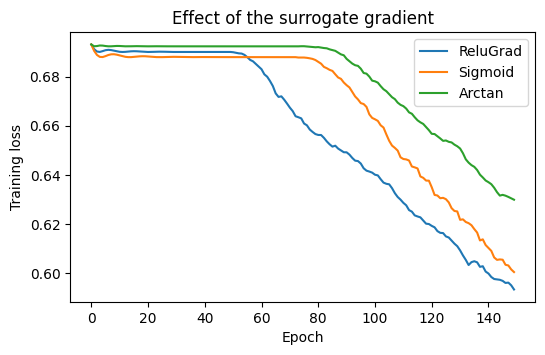

In [5]:
plt.figure(figsize=(6, 3.5))
for name, losses in curves.items():
    plt.plot(np.asarray(losses), label=name)
plt.xlabel('Epoch'); plt.ylabel('Training loss'); plt.legend()
plt.title('Effect of the surrogate gradient')
plt.show()

## See also

- :doc:`/concepts/differentiability` — surrogate gradients and BPTT explained.
- :doc:`train-readouts` — add a trainable rate readout.
- :doc:`train-long-rollouts-checkpoint` — bound memory for long sequences.